In [1]:
from google.colab import files

uploaded = files.upload()

Saving stroke_prediction_dataset.csv to stroke_prediction_dataset.csv


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

In [19]:
import pandas as pd

df = pd.read_csv("stroke_prediction_dataset.csv")

df.head()

,Patient ID,Patient Name,Age,Gender,Hypertension,Heart Disease,Marital Status,Work Type,Residence Type,Average Glucose Level,...,Alcohol Intake,Physical Activity,Stroke History,Family History of Stroke,Dietary Habits,Stress Levels,Blood Pressure Levels,Cholesterol Levels,Symptoms,Diagnosis
0,18153,Mamooty Khurana,56,Male,0,1,Married,Self-employed,Rural,130.91,...,Social Drinker,Moderate,0,Yes,Vegan,3.48,140/108,"HDL: 68, LDL: 133","Difficulty Speaking, Headache",Stroke
1,62749,Kaira Subramaniam,80,Male,0,0,Single,Self-employed,Urban,183.73,...,Never,Low,0,No,Paleo,1.73,146/91,"HDL: 63, LDL: 70","Loss of Balance, Headache, Dizziness, Confusion",Stroke
2,32145,Dhanush Balan,26,Male,1,1,Married,Never Worked,Rural,189.00,...,Rarely,High,0,Yes,Paleo,7.31,154/97,"HDL: 59, LDL: 95","Seizures, Dizziness",Stroke
3,6154,Ivana Baral,73,Male,0,0,Married,Never Worked,Urban,185.29,...,Frequent Drinker,Moderate,0,No,Paleo,5.35,174/81,"HDL: 70, LDL: 137","Seizures, Blurred Vision, Severe Fatigue, Head...",No Stroke
4,48973,Darshit Jayaraman,51,Male,1,1,Divorced,Self-employed,Urban,177.34,...,Rarely,Low,0,Yes,Pescatarian,6.84,121/95,"HDL: 65, LDL: 68",Difficulty Speaking,Stroke


In [20]:
df.shape

(15000, 22)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Patient ID                15000 non-null  int64  
 1   Patient Name              15000 non-null  object 
 2   Age                       15000 non-null  int64  
 3   Gender                    15000 non-null  object 
 4   Hypertension              15000 non-null  int64  
 5   Heart Disease             15000 non-null  int64  
 6   Marital Status            15000 non-null  object 
 7   Work Type                 15000 non-null  object 
 8   Residence Type            15000 non-null  object 
 9   Average Glucose Level     15000 non-null  float64
 10  Body Mass Index (BMI)     15000 non-null  float64
 11  Smoking Status            15000 non-null  object 
 12  Alcohol Intake            15000 non-null  object 
 13  Physical Activity         15000 non-null  object 
 14  Stroke

## Member 4 - Scaling and Normalization

### Introduction

Numerical attributes often have different value ranges.

For example, Age ranges from 18 to 90, while Stress Levels range from 0 to 10.

Feature scaling helps ensure that all numerical attributes contribute equally during machine learning model training.

For this task, StandardScaler was used.

In [21]:
columns_to_scale = [
    'Age',
    'Average Glucose Level',
    'Body Mass Index (BMI)',
    'Stress Levels'
]

In [22]:
df[columns_to_scale].head()

,Age,Average Glucose Level,Body Mass Index (BMI),Stress Levels
0,56,130.91,22.37,3.48
1,80,183.73,32.57,1.73
2,26,189.00,20.32,7.31
3,73,185.29,27.50,5.35
4,51,177.34,29.06,6.84


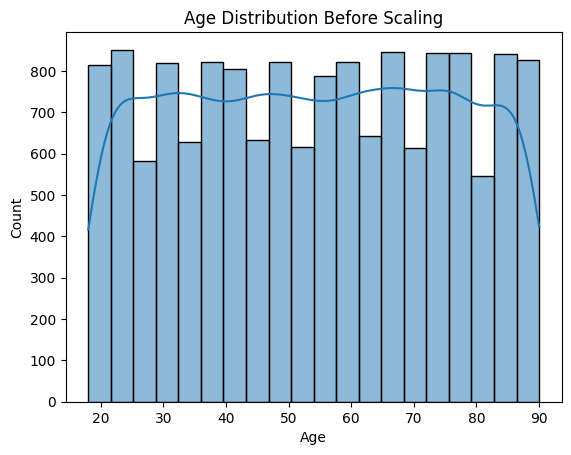

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['Age'], bins=20, kde=True)

plt.title("Age Distribution Before Scaling")

plt.savefig("age_before_scaling.png")

plt.show()

### Before Scaling

The selected attributes contain values with different ranges and units.

Scaling is required to bring these features onto a common scale.

In [24]:
scaler = StandardScaler()

df[columns_to_scale] = scaler.fit_transform(
    df[columns_to_scale]
)

In [25]:
df[columns_to_scale].head()

,Age,Average Glucose Level,Body Mass Index (BMI),Stress Levels
0,0.093263,0.036180,-0.705993,-0.536939
1,1.232733,1.340814,0.704803,-1.146031
2,-1.331076,1.470981,-0.989536,0.796103
3,0.900388,1.379345,0.003554,0.113920
4,-0.144127,1.182983,0.219323,0.632518


In [26]:
df[columns_to_scale].describe()

,Age,Average Glucose Level,Body Mass Index (BMI),Stress Levels
count,1.500000e+04,1.500000e+04,1.500000e+04,1.500000e+04
mean,1.193712e-16,-1.534772e-16,-2.150576e-16,-1.487403e-16
std,1.000033e+00,1.000033e+00,1.000033e+00,1.000033e+00
min,-1.710900e+00,-1.715271e+00,-1.723979e+00,-1.748163e+00
25%,-8.562965e-01,-8.627013e-01,-8.733523e-01,-8.641086e-01
50%,-1.693380e-03,-1.346645e-02,-7.510692e-03,9.503930e-03
75%,8.529097e-01,8.681250e-01,8.638635e-01,8.691944e-01
max,1.707513e+00,1.742677e+00,1.732471e+00,1.732365e+00


### Scaling Results

The following numerical attributes were standardized:

- Age
- Average Glucose Level
- Body Mass Index (BMI)
- Stress Levels

Feature scaling reduces the effect of differing value ranges and improves dataset consistency for future machine learning applications.

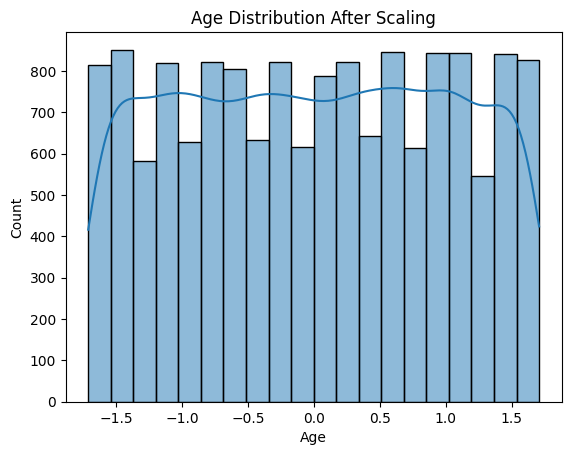

In [27]:
sns.histplot(df['Age'], bins=20, kde=True)

plt.title("Age Distribution After Scaling")

plt.savefig("age_after_scaling.png")

plt.show()

## Conclusion

Scaling and normalization were successfully applied using StandardScaler.

The selected numerical attributes were transformed to a common scale with a mean close to 0 and a standard deviation close to 1.

This preprocessing step improves data consistency and prepares the dataset for future machine learning and predictive modeling tasks.